<a href="https://colab.research.google.com/github/Anki02-07/Prodegy_Infotech/blob/main/Prodegy_Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
pip install pandas matplotlib seaborn folium

In [3]:
import pandas as pd

data = pd.read_csv("/content/US_accidentsMatch2023.csv")  # change path if needed

print(data.shape)
print(data.head())
print(data.columns)

(24637, 46)
   Unnamed: 0  Severity           Start_Time  Start_Lat   Start_Lng  \
0           0       3.0  2017-01-01 00:17:36  37.925392 -122.320595   
1           1       3.0  2017-01-01 00:26:08  37.878185 -122.307175   
2           2       2.0  2017-01-01 00:53:41  38.014820 -121.640579   
3           3       3.0  2017-01-01 01:18:51  37.912056 -122.323982   
4           4       3.0  2017-01-01 01:20:12  37.925392 -122.320595   

   Distance(mi)                                        Description  \
0          0.01  Accident on I-80 Westbound at Exit 15 Cutting ...   
1          0.01  Accident on I-580 Southbound at Exit 12 I-80 I...   
2          0.00  Accident on Taylor Rd Southbound at Bethel Isl...   
3          0.01  Lane blocked and queueing traffic due to accid...   
4          0.01  Queueing traffic due to accident on I-80 Westb...   

        Street        City        County  ...            Star_Time  Clear  \
0       I-80 E  El Cerrito  Contra Costa  ...  2017-01-01 00:17

/tmp/ipython-input-403/585436967.py:3: DtypeWarning: Columns (41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/US_accidentsMatch2023.csv")  # change path if needed


In [4]:
# convert time column
data["Start_Time"] = pd.to_datetime(data["Start_Time"])

# extract hour of day
data["Hour"] = data["Start_Time"].dt.hour

# drop rows with missing key values
data = data.dropna(subset=["Weather_Condition", "Visibility(mi)", "Hour", "Start_Lat", "Start_Lng"])

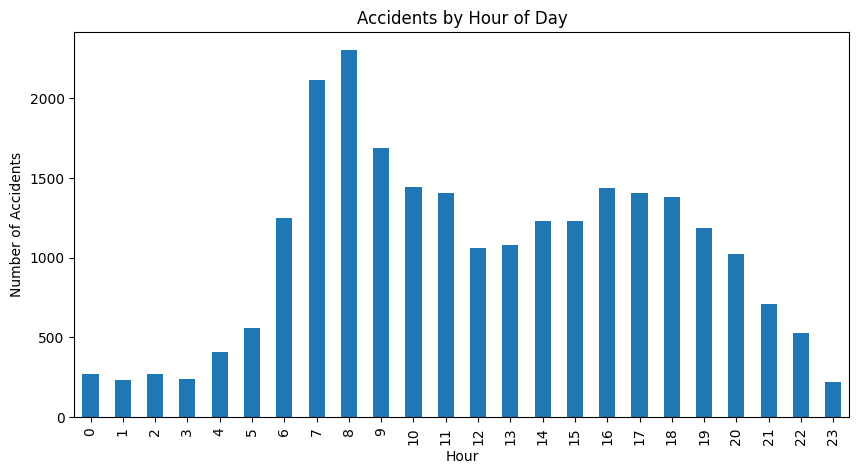

In [5]:
import matplotlib.pyplot as plt

data["Hour"].value_counts().sort_index().plot(kind="bar", figsize=(10,5))

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

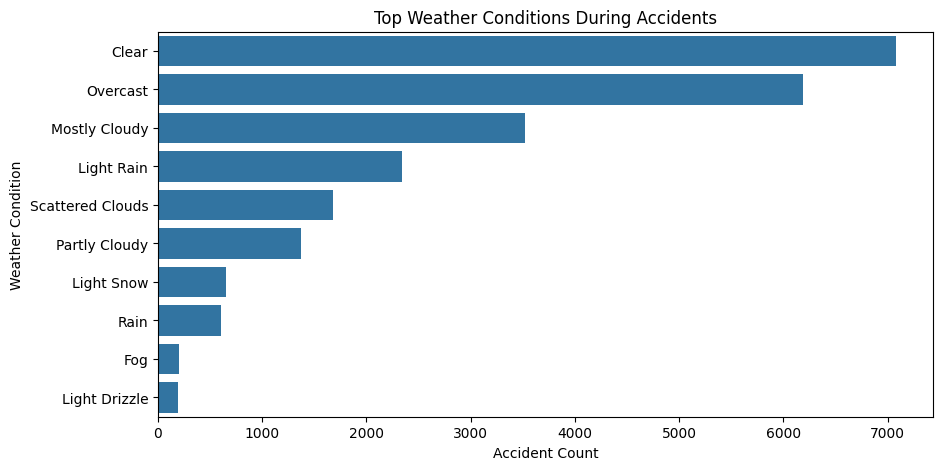

In [6]:
import seaborn as sns

top_weather = data["Weather_Condition"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_weather.values, y=top_weather.index)

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Accident Count")
plt.ylabel("Weather Condition")
plt.show()

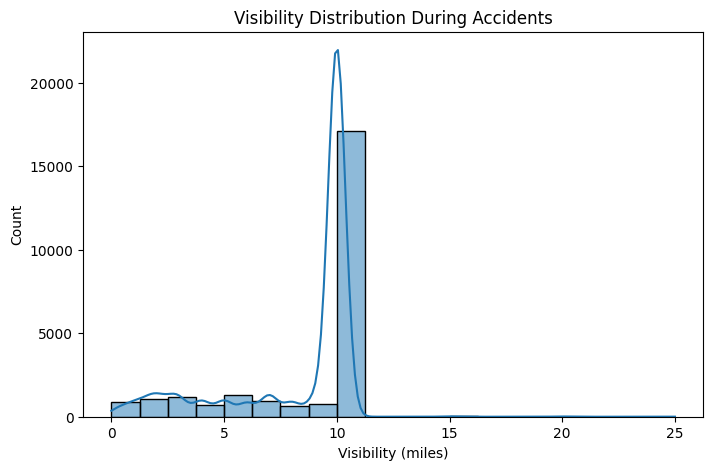

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data["Visibility(mi)"], bins=20, kde=True)

plt.title("Visibility Distribution During Accidents")
plt.xlabel("Visibility (miles)")
plt.show()

In [8]:
import folium

# sample data (large dataset may crash map)
sample = data.sample(2000)

map_center = [sample["Start_Lat"].mean(), sample["Start_Lng"].mean()]
accident_map = folium.Map(location=map_center, zoom_start=4)

for lat, lng in zip(sample["Start_Lat"], sample["Start_Lng"]):
    folium.CircleMarker(
        location=[lat, lng],
        radius=2,
        color="red",
        fill=True
    ).add_to(accident_map)

accident_map

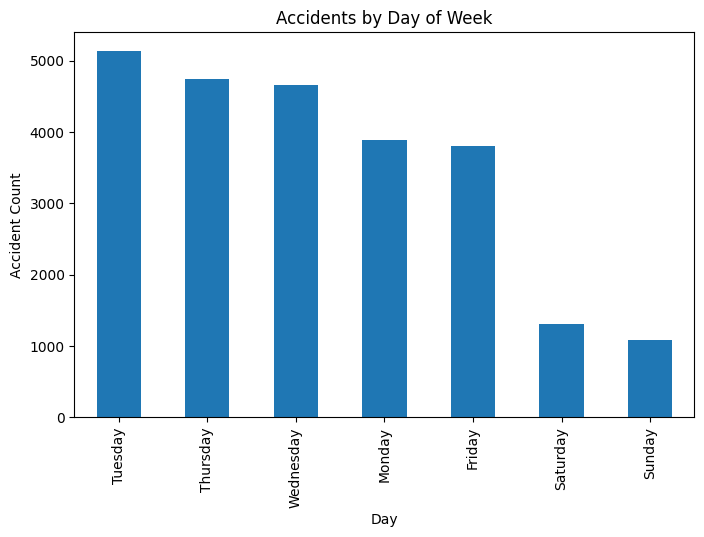

In [9]:
data["Day"] = data["Start_Time"].dt.day_name()

data["Day"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Accident Count")
plt.show()